# **Mô tả dữ liệu - Dự đoán nguy cơ mắc bệnh suy tim**

**1) Giới thiệu**:

Bệnh tim mạch (CVDs) là nguyên nhân gây tử vong hàng đầu trên toàn cầu, cướp đi sinh mạng của khoảng 17,9 triệu người mỗi năm, chiếm 31% tổng số ca tử vong trên thế giới. Trong đó, 4/5 trường hợp tử vong do bệnh tim mạch là do nhồi máu cơ tim và đột quỵ, và 1/3 số ca tử vong xảy ra ở những người dưới 70 tuổi. Suy tim là một trong những hậu quả phổ biến của bệnh tim mạch.


Bộ dữ liệu này chứa 11 đặc trưng có thể được sử dụng để dự đoán khả năng mắc bệnh tim. Những người có nguy cơ cao (do huyết áp cao, tiểu đường, mỡ máu cao hoặc có bệnh tim trước đó) cần được phát hiện và quản lý sớm, trong đó mô hình học máy có thể hỗ trợ hiệu quả.

------------------------------------------------------

**2) Thông tin các thuộc tính**

+ Age: Tuổi của bệnh nhân (đơn vị: năm)

+ Sex: Giới tính của bệnh nhân (M: Nam, F: Nữ)

+ ChestPainType: Loại cơn đau ngực: TA (Đau thắt ngực điển hình), ATA (Đau thắt ngực không điển hình), NAP (Đau không do tim), ASY (Không có triệu chứng)

+ RestingBP: Huyết áp khi nghỉ (đơn vị: mmHg)

+ Cholesterol: Mức cholesterol trong máu (đơn vị: mg/dl)

+ FastingBS: Chỉ số đường huyết khi đói (1 nếu > 120 mg/dl, 0 nếu ngược lại)

+ RestingECG: Kết quả điện tim khi nghỉ: Normal (Bình thường), ST (Bất thường sóng ST-T), LVH (Phì đại thất trái)

+ MaxHR: Nhịp tim tối đa đạt được (giá trị từ 60 đến 202)

+ ExerciseAngina: Cơn đau thắt ngực khi tập luyện (Y: Có, N: Không)

+ Oldpeak: Độ chênh ST khi gắng sức (Đơn vị: mm)

+ ST_Slope: Độ dốc đoạn ST khi gắng sức: Up (Dốc lên), Flat (Bằng phẳng), Down (Dốc xuống)

+ HeartDisease: Nhãn đầu ra (1: Mắc bệnh tim, 0: Bình thường)

------------------------------------------------------
**3) Nguồn dữ liệu**

Bộ dữ liệu được tổng hợp từ 5 bộ dữ liệu khác nhau, tạo thành tập dữ liệu bệnh tim lớn nhất dành cho nghiên cứu:
+ Cleverland: 303 mẫu
+ Hungarian: 294 mẫu
+ Switzerland: 123 mẫu
+ Long Beach VA: 200 mẫu
+ Stalog DataSet: 270 mẫu

Từ nguồn dữ liệu lên ta rút ra được:
+ Tổng số mẫu 1100
+ Số mẫu trùng lặp: 272
+ Tổng số mẫu cuối cùng: 918

------------------------------------------------------
**4) Ứng dụng**
+ Hỗ trợ hệ thống cảnh báo sớm về nguy cơ mắc bệnh suy tim
+ Giúp các bác sĩ đánh giá nguy cơ bệnh tim dựa trên các yếu tố đầu vào
+ Ứng dụng Machine Learning và AI trong chẩn đoán bệnh tim

Dữ liệu này có thể được sử dụng để huấn luyện các mô hình Machine Learning nhằm dự đoán nguy cơ mắc bệnh suy tim, góp phần cải thiện việc phát hiện sớm và đưa ra phương pháp điều trị phù hợp.

# CÀI ĐẶT SPARK

In [1]:
# 1. Cài đặt pyspark và findspark
!pip install -q pyspark findspark

# 2. Khởi tạo Spark để Colab có thể nhận diện
import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

print("Spark đã được cài đặt và khởi tạo thành công. Biến 'spark' đã sẵn sàng để sử dụng.")

Spark đã được cài đặt và khởi tạo thành công. Biến 'spark' đã sẵn sàng để sử dụng.


# Import thư viện và tải lên bộ dữ liệu

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = SparkSession.builder.appName("HeartDiseaseSpark").getOrCreate()

df = spark.read.csv("heart.csv", header=True, inferSchema=True)

df.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- Sex: string (nullable = true)
 |-- ChestPainType: string (nullable = true)
 |-- RestingBP: integer (nullable = true)
 |-- Cholesterol: integer (nullable = true)
 |-- FastingBS: integer (nullable = true)
 |-- RestingECG: string (nullable = true)
 |-- MaxHR: integer (nullable = true)
 |-- ExerciseAngina: string (nullable = true)
 |-- Oldpeak: double (nullable = true)
 |-- ST_Slope: string (nullable = true)
 |-- HeartDisease: integer (nullable = true)



In [ ]:
df.show(5)

+---+---+-------------+---------+-----------+---------+----------+-----+--------------+-------+--------+------------+
|Age|Sex|ChestPainType|RestingBP|Cholesterol|FastingBS|RestingECG|MaxHR|ExerciseAngina|Oldpeak|ST_Slope|HeartDisease|
+---+---+-------------+---------+-----------+---------+----------+-----+--------------+-------+--------+------------+
| 40|  M|          ATA|      140|        289|        0|    Normal|  172|             N|    0.0|      Up|           0|
| 49|  F|          NAP|      160|        180|        0|    Normal|  156|             N|    1.0|    Flat|           1|
| 37|  M|          ATA|      130|        283|        0|        ST|   98|             N|    0.0|      Up|           0|
| 48|  F|          ASY|      138|        214|        0|    Normal|  108|             Y|    1.5|    Flat|           1|
| 54|  M|          NAP|      150|        195|        0|    Normal|  122|             N|    0.0|      Up|           0|
+---+---+-------------+---------+-----------+---------+-

In [ ]:
df.describe().show()

+-------+------------------+----+-------------+------------------+------------------+-------------------+----------+------------------+--------------+------------------+--------+-------------------+
|summary|               Age| Sex|ChestPainType|         RestingBP|       Cholesterol|          FastingBS|RestingECG|             MaxHR|ExerciseAngina|           Oldpeak|ST_Slope|       HeartDisease|
+-------+------------------+----+-------------+------------------+------------------+-------------------+----------+------------------+--------------+------------------+--------+-------------------+
|  count|               918| 918|          918|               918|               918|                918|       918|               918|           918|               918|     918|                918|
|   mean|53.510893246187365|NULL|         NULL|132.39651416122004| 198.7995642701525|0.23311546840958605|      NULL|136.80936819172112|          NULL|0.8873638344226581|    NULL| 0.5533769063180828|
| std

# Phân tích dữ liệu

**Kiểm tra phân phối dữ liệu**

In [3]:
pandas_df = df.toPandas()

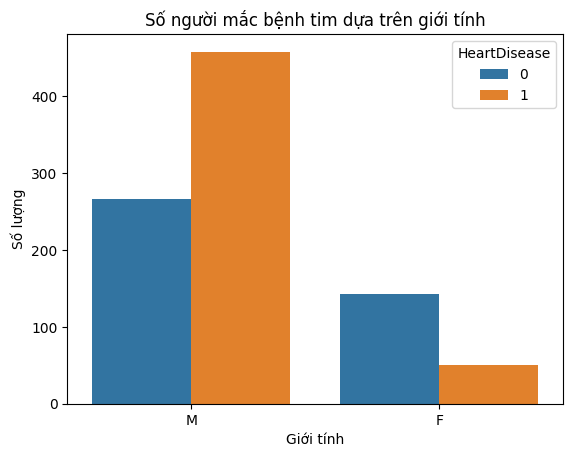

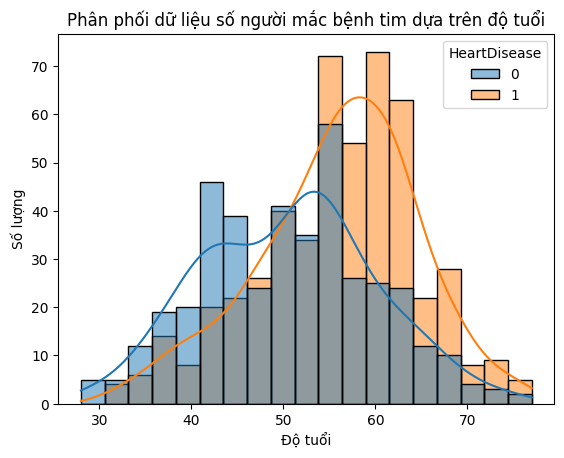

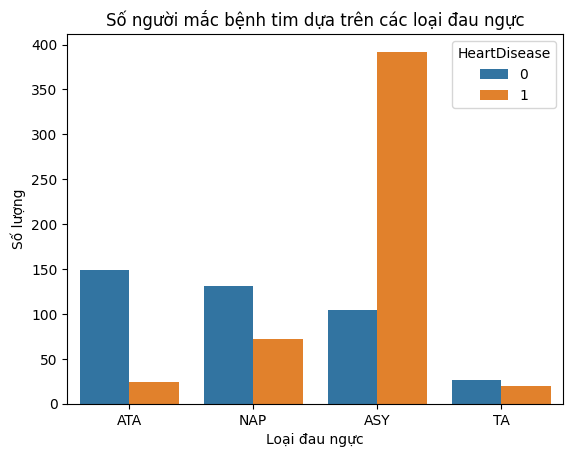

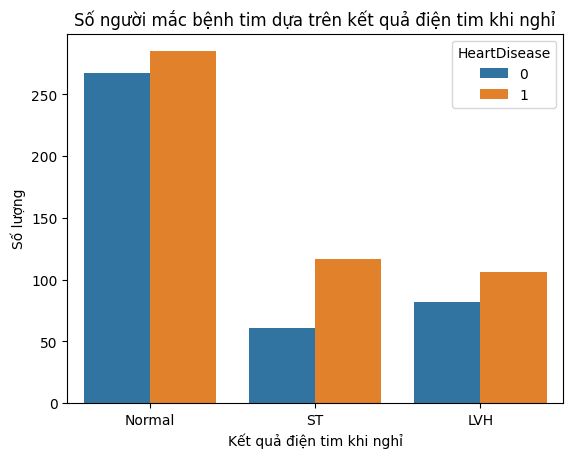

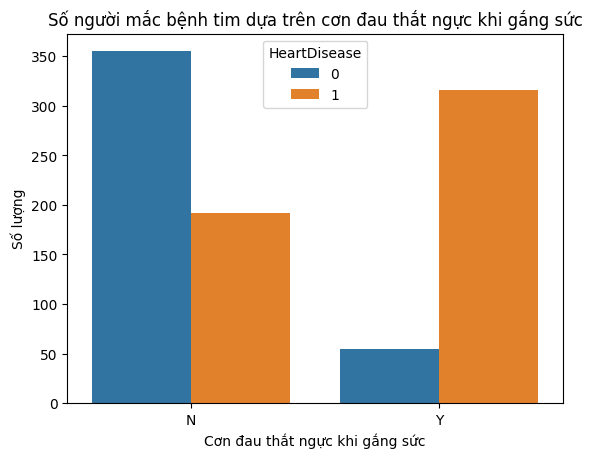

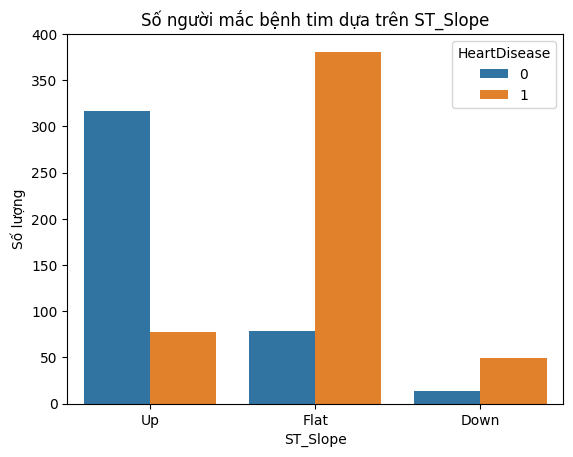

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Biểu đồ: Giới tính vs HeartDisease
sns.countplot(x='Sex', hue='HeartDisease', data=pandas_df)
plt.title('Số người mắc bệnh tim dựa trên giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.show()

# Tuổi vs HeartDisease
sns.histplot(data=pandas_df, x='Age', hue='HeartDisease', kde=True)
plt.title('Phân phối dữ liệu số người mắc bệnh tim dựa trên độ tuổi')
plt.xlabel('Độ tuổi')
plt.ylabel('Số lượng')
plt.show()

# ChestPainType vs HeartDisease
sns.countplot(x='ChestPainType', hue='HeartDisease', data=pandas_df)
plt.title('Số người mắc bệnh tim dựa trên các loại đau ngực')
plt.xlabel('Loại đau ngực')
plt.ylabel('Số lượng')
plt.show()

# RestingECG vs HeartDisease
sns.countplot(x='RestingECG', hue='HeartDisease', data=pandas_df)
plt.title('Số người mắc bệnh tim dựa trên kết quả điện tim khi nghỉ')
plt.xlabel('Kết quả điện tim khi nghỉ')
plt.ylabel('Số lượng')
plt.show()

# ExerciseAngina vs HeartDisease
sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=pandas_df)
plt.title('Số người mắc bệnh tim dựa trên cơn đau thắt ngực khi gắng sức')
plt.xlabel('Cơn đau thắt ngực khi gắng sức')
plt.ylabel('Số lượng')
plt.show()

# ST_Slope vs HeartDisease
sns.countplot(x='ST_Slope', hue='HeartDisease', data=pandas_df)
plt.title('Số người mắc bệnh tim dựa trên ST_Slope')
plt.xlabel('ST_Slope')
plt.ylabel('Số lượng')
plt.show()

**Phân phối dữ liệu của các biến numerical với biến mục tiêu**

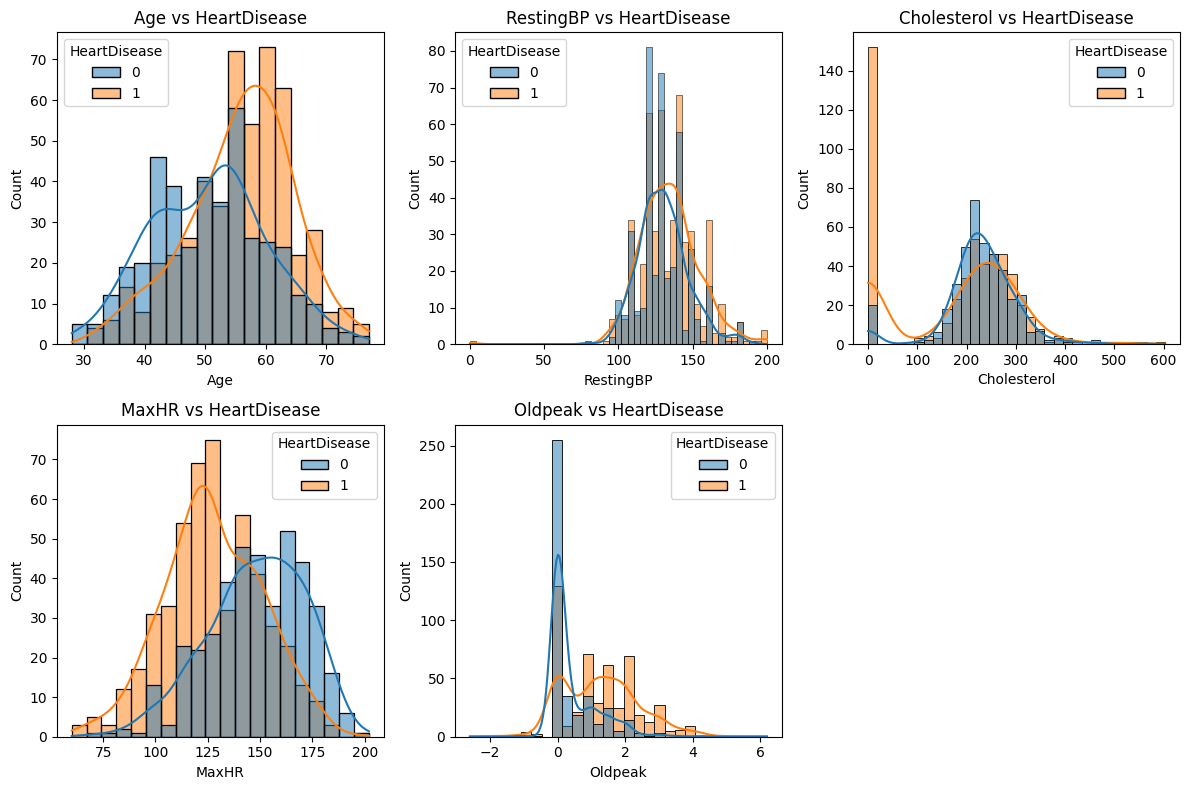

In [6]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Histogram nhiều biến
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=pandas_df, x=feature, hue='HeartDisease', kde=True, ax=axes[i])
    axes[i].set_title(f'{feature} vs HeartDisease')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


**1. Age vs HeartDisease**

- Người mắc bệnh tim (màu cam) có xu hướng cao tuổi hơn so với người không mắc bệnh tim.
- Đỉnh phân phối của nhóm mắc bệnh tim lệch phải, cho thấy nguy cơ mắc bệnh tăng lên theo tuổi.

**2. RestingBP vs HeartDisease (Huyết áp khi nghỉ)**

- Huyết áp nghỉ ngơi của cả hai nhóm có phân phối khá tương đồng, tập trung chủ yếu trong khoảng 120-140 mmHg.
- Không có sự khác biệt rõ rệt giữa hai nhóm.

**3. Cholesterol vs HeartDisease**

- Có một lượng lớn bệnh nhân không mắc bệnh tim có mức cholesterol rất thấp, có thể do điều trị hoặc đặc điểm của tập dữ liệu.
- Nhìn chung, phân phối cholesterol giữa hai nhóm khá tương đồng, nhưng có xu hướng hơi cao hơn ở nhóm mắc bệnh tim.

**4. MaxHR vs HeartDisease (Nhịp tim tối đa đạt được)**

- Người mắc bệnh tim có xu hướng có nhịp tim tối đa thấp hơn so với người không mắc bệnh tim.
- Điều này có thể liên quan đến việc tim của họ không thể đạt đến mức nhịp tim cao do các vấn đề về tuần hoàn.

**5. Oldpeak vs HeartDisease (Độ chênh ST trong ECG khi vận động so với lúc nghỉ)**

- Người mắc bệnh tim có giá trị Oldpeak cao hơn, điều này có thể liên quan đến dấu hiệu thiếu máu cục bộ (ischemia).
- Phân phối của nhóm mắc bệnh tim bị lệch phải, cho thấy rằng mức độ nghiêm trọng của sự chênh lệch ST có thể là một yếu tố quan trọng trong dự đoán bệnh tim.

**Tóm tắt**:
Age, MaxHR, và Oldpeak có ảnh hưởng đáng kể đến nguy cơ mắc bệnh tim.
RestingBP và Cholesterol không có sự khác biệt rõ rệt giữa hai nhóm.
MaxHR thấp và Oldpeak cao là những dấu hiệu đáng chú ý ở nhóm mắc bệnh tim.

**Phân phối dữ liệu giữa độ tuổi và các đặc trưng khác**

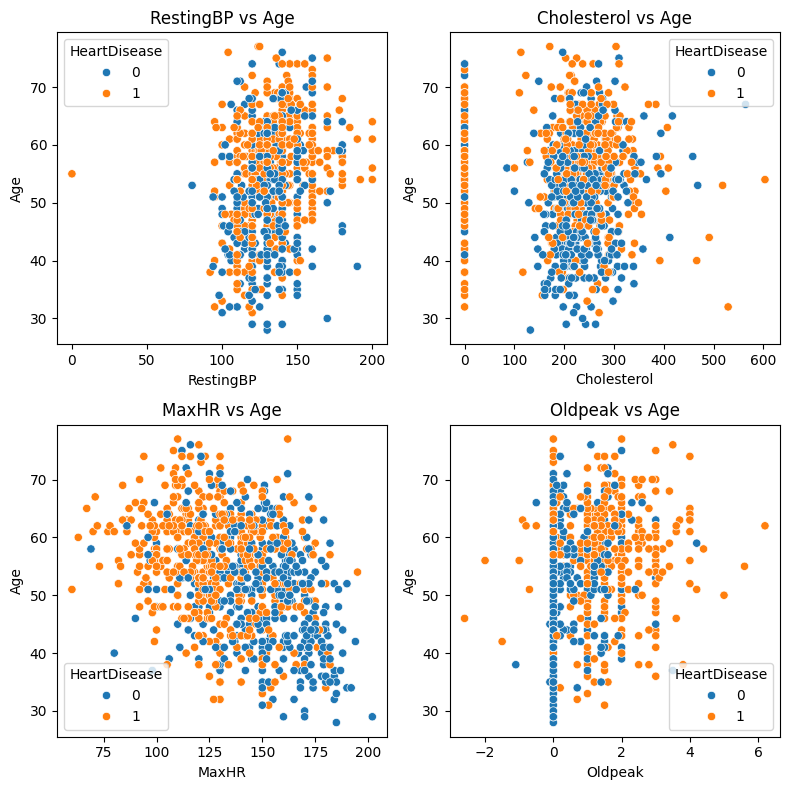

In [ ]:
n_rows, n_cols = 2, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features[1:]):  # bỏ Age
    sns.scatterplot(data=pandas_df, x=feature, y='Age', hue='HeartDisease', ax=axes[i])
    axes[i].set_title(f'{feature} vs Age')

plt.tight_layout()
plt.show()


**Kiểm tra mất cân bằng dữ liệu**

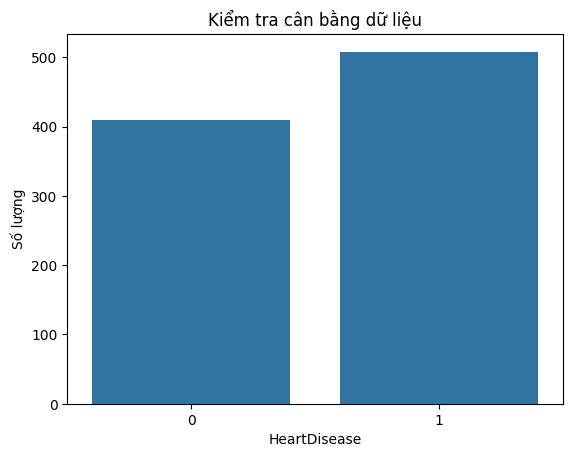

In [ ]:
# HeartDisease distribution
sns.countplot(x='HeartDisease', data=pandas_df)
plt.title('Kiểm tra cân bằng dữ liệu')
plt.xlabel('HeartDisease')
plt.ylabel('Số lượng')
plt.show()

**Ma trận tương quan**

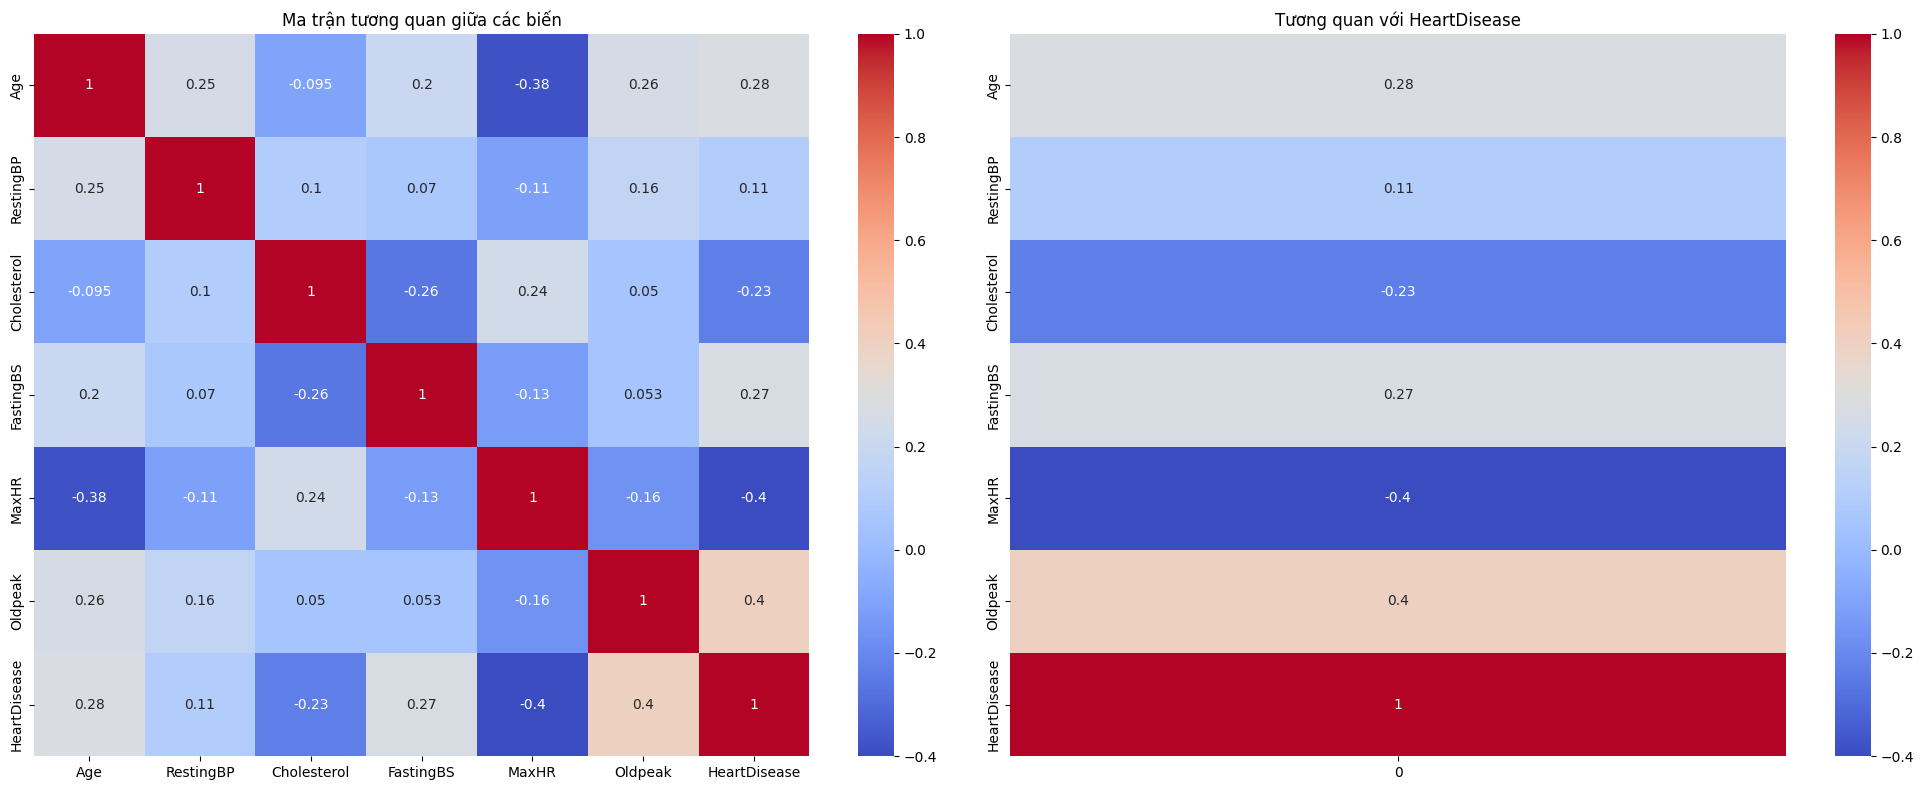

In [ ]:
pandas_df_encoded = df.toPandas()

vector_cols = [col for col in pandas_df_encoded.columns if pandas_df_encoded[col].apply(lambda x: isinstance(x, list) or "DenseVector" in str(type(x))).any()]
original_categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
pandas_df_encoded = pandas_df_encoded.drop(columns=vector_cols + original_categorical_cols)

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
sns.heatmap(pandas_df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Ma trận tương quan giữa các biến')

plt.subplot(1, 2, 2)
sns.heatmap(pandas_df_encoded.corrwith(pandas_df_encoded['HeartDisease']).to_frame(), annot=True, cmap='coolwarm')
plt.title('Tương quan với HeartDisease')

plt.tight_layout()
plt.show()

# Tiền xử lý dữ liệu

In [7]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

indexers = [StringIndexer(inputCol=col, outputCol=col+"_index") for col in categorical_cols]

for indexer in indexers:
    df = indexer.fit(df).transform(df)

for col_name in categorical_cols:
    df = df.drop(col_name).withColumnRenamed(col_name + "_index", col_name)


In [8]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

assembler = VectorAssembler(inputCols=numerical_cols, outputCol="numerical_feature")
df = assembler.transform(df)

scaler = StandardScaler(inputCol="numerical_feature", outputCol="scaled_feature")
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

all_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'scaled_feature']
assembler_all = VectorAssembler(inputCols=all_features, outputCol="features")
df = assembler_all.transform(df)

final_df = df.select("features", col("HeartDisease").alias("label"))


In [9]:
train_data, test_data = final_df.randomSplit([0.8, 0.2], seed=42)

# Huấn luyện mô hình

In [ ]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import numpy as np

# Danh sách mô hình
models = [
    LogisticRegression(labelCol="label", featuresCol="features"),
    RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100),
    GBTClassifier(labelCol="label", featuresCol="features")
]

# Khởi tạo evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Variables to store fitted models for later use
rf_fitted_model = None
gbt_fitted_model = None

for model in models:
    print(f"\n=== {model.__class__.__name__} ===")
    fitted_model = model.fit(train_data)
    predictions = fitted_model.transform(test_data)

    # Store the fitted model if it's GBTClassifier or RandomForestClassifier
    if isinstance(model, RandomForestClassifier):
        rf_fitted_model = fitted_model
    elif isinstance(model, GBTClassifier):
        gbt_fitted_model = fitted_model

    # Accuracy
    evaluator.setMetricName("accuracy")
    acc = evaluator.evaluate(predictions)

    # Precision
    evaluator.setMetricName("weightedPrecision")
    prec = evaluator.evaluate(predictions)

    # Recall
    evaluator.setMetricName("weightedRecall")
    rec = evaluator.evaluate(predictions)

    # F1-score
    evaluator.setMetricName("f1")
    f1 = evaluator.evaluate(predictions)

    # In kết quả
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")


=== LogisticRegression ===
Accuracy: 0.8523
Precision: 0.8555
Recall: 0.8523
F1 Score: 0.8514

=== RandomForestClassifier ===
Accuracy: 0.8725
Precision: 0.8798
Recall: 0.8725
F1 Score: 0.8712

=== GBTClassifier ===
Accuracy: 0.8658
Precision: 0.8675
Recall: 0.8658
F1 Score: 0.8652


**Nhận xét:** Chọn ra 2 mô hình có chỉ số đánh giá cao nhất là Random Forest và Gradient Boosting để tiếp tục tối ưu hóa

##  Vì sao Recall quan trọng trong bài toán chẩn đoán phát hiện bệnh suy tim?

- Recall đo lường khả năng mô hình **phát hiện đúng** những bệnh nhân thật sự mắc bệnh.
- **Công thức**:
  $$
  Recall = \frac{TP}{TP + FN}
  $$
- **TP (True Positive):** Dự đoán đúng người có bệnh.
- **FN (False Negative):** Dự đoán **sai** là không bệnh nhưng thực tế **có bệnh** (bỏ sót bệnh nhân).

**Trong bài toán bệnh tim, bỏ sót bệnh nhân (FN) có thể gây hậu quả nghiêm trọng**:
- Nếu mô hình **bỏ sót bệnh nhân thực sự mắc bệnh (FN cao)**, họ có thể không được điều trị kịp thời.
- Trong y tế, một **FN nguy hiểm hơn FP** vì hậu quả sức khỏe có thể dẫn đến **biến chứng hoặc tử vong**.

**Ví dụ**:
- Nếu một bệnh nhân **bị bệnh tim thực sự** nhưng hệ thống chẩn đoán dự đoán **không bệnh** → Họ có thể không đi khám, bỏ lỡ cơ hội điều trị sớm.
- Ngược lại, nếu mô hình báo nhầm (**FP – dự đoán có bệnh nhưng thực tế không bệnh**), người đó chỉ phải làm thêm xét nghiệm, ít gây rủi ro.
**Vậy nên, cần ưu tiên Recall cao để hạn chế FN!**  

# **1. Random Forest**

**Feature Importance**

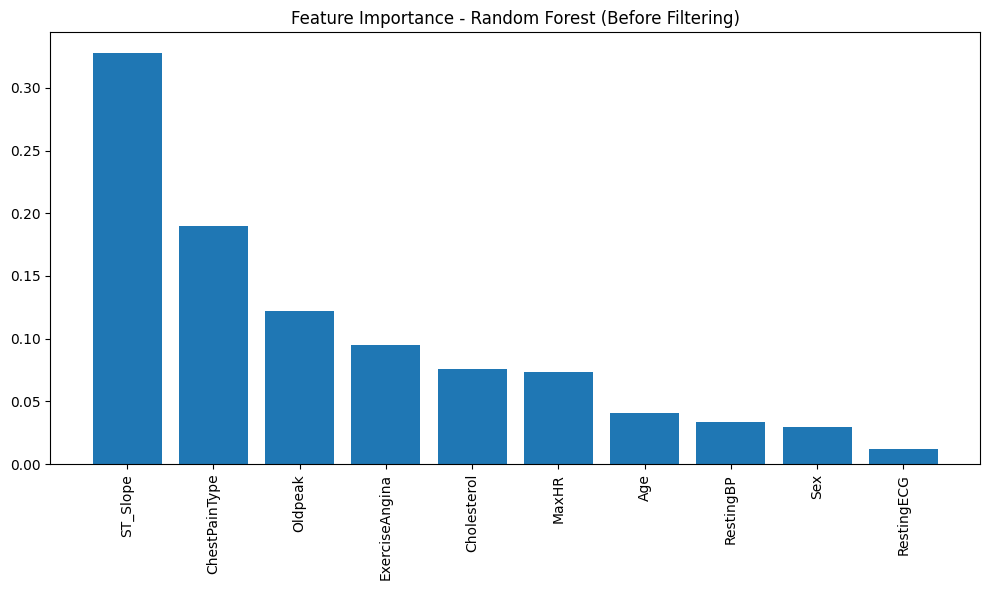

In [12]:
importances = rf_fitted_model.featureImportances.toArray()

feature_names_for_importance = categorical_cols + numerical_cols

importances = importances[:len(feature_names_for_importance)]

feature_importance_pairs = list(zip(feature_names_for_importance, importances))

sorted_pairs_desc = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)
features_sorted, importances_sorted = zip(*sorted_pairs_desc)

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Random Forest (Before Filtering)")
plt.bar(range(len(importances_sorted)), importances_sorted, align="center")
plt.xticks(range(len(importances_sorted)), features_sorted, rotation=90)
plt.tight_layout()
plt.show()

**Loại bỏ đặc trưng ít quan trọng**

In [13]:
sorted_pairs = sorted(feature_importance_pairs, key=lambda x: x[1])

important_features = [feature for feature, _ in sorted_pairs[2:]]

print("Các đặc trưng quan trọng (sau khi loại 2 đặc trưng ít nhất):", important_features)


Các đặc trưng quan trọng (sau khi loại 2 đặc trưng ít nhất): ['RestingBP', 'Age', 'MaxHR', 'Cholesterol', 'ExerciseAngina', 'Oldpeak', 'ChestPainType', 'ST_Slope']


**Huấn luyện lại mô hình**

In [14]:
from pyspark.ml.feature import VectorAssembler

filtered_assembler = VectorAssembler(inputCols=important_features, outputCol="filtered_features")
data_filtered = filtered_assembler.transform(df)

final_data_filtered = data_filtered.select("filtered_features", col("HeartDisease").alias("label")) # Use HeartDisease column

train_data_filtered, test_data_filtered = final_data_filtered.randomSplit([0.8, 0.2], seed=42)

In [15]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


rf_new = RandomForestClassifier(labelCol="label", featuresCol="filtered_features", numTrees=100)
rf_new_model = rf_new.fit(train_data_filtered)

predictions_filtered = rf_new_model.transform(test_data_filtered)

evaluator_filtered = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Accuracy
evaluator_filtered.setMetricName("accuracy")
acc_filtered = evaluator_filtered.evaluate(predictions_filtered)

# Precision
evaluator_filtered.setMetricName("weightedPrecision")
prec_filtered = evaluator_filtered.evaluate(predictions_filtered)

# Recall
evaluator_filtered.setMetricName("weightedRecall")
rec_filtered = evaluator_filtered.evaluate(predictions_filtered)

# F1-score
evaluator_filtered.setMetricName("f1")
f1_filtered = evaluator_filtered.evaluate(predictions_filtered)

# In kết quả
print(f"\n=== RandomForestClassifier with Filtered Features ===")
print(f"Accuracy: {acc_filtered:.4f}")
print(f"Precision: {prec_filtered:.4f}")
print(f"Recall: {rec_filtered:.4f}")
print(f"F1 Score: {f1_filtered:.4f}")


=== RandomForestClassifier with Filtered Features ===
Accuracy: 0.8591
Precision: 0.8587
Recall: 0.8591
F1 Score: 0.8578


**Nhận thấy rằng kết quả sau khi huấn luyện lại mô hình kém hơn so với ban đầu -> tối ưu hóa trên tập dữ liệu gốc.**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 20.1 MB/s eta 0:00:00


In [ ]:
#import optuna
#from pyspark.ml.classification import RandomForestClassifier
#from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def objective(trial):
    rf = RandomForestClassifier(
        numTrees=trial.suggest_int("numTrees", 50, 300, step=50),
        maxDepth=trial.suggest_int("maxDepth", 2, 30, step=2),
        labelCol="label",
        featuresCol="features",
        seed=42
    )

    model = rf.fit(train_data)
    predictions = model.transform(test_data)

    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    )
    score = evaluator.evaluate(predictions)
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)
print("Best Recall Score:", study.best_value)

best_model_rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=study.best_params["numTrees"],
    maxDepth=study.best_params["maxDepth"],
    seed=42
)

best_model_rf_fitted = best_model_rf.fit(train_data)

predictions_best_rf = best_model_rf_fitted.transform(test_data)

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

print("*" * 100)
print(f"Accuracy on test set: {evaluator_acc.evaluate(predictions_best_rf):.4f}")
print(f"Recall on test set: {evaluator_rec.evaluate(predictions_best_rf):.4f}")
print(f"Precision on test set: {evaluator_prec.evaluate(predictions_best_rf):.4f}")
print(f"F1 Score on test set: {evaluator_f1.evaluate(predictions_best_rf):.4f}")


[I 2025-08-05 09:34:43,831] A new study created in memory with name: no-name-c339b5b8-aff4-4b8f-bd20-e9f254ffc5b0
[I 2025-08-05 09:34:48,641] Trial 0 finished with value: 0.8791946308724833 and parameters: {'numTrees': 50, 'maxDepth': 14}. Best is trial 0 with value: 0.8791946308724833.
[I 2025-08-05 09:35:04,900] Trial 1 finished with value: 0.8859060402684564 and parameters: {'numTrees': 300, 'maxDepth': 22}. Best is trial 1 with value: 0.8859060402684564.
[I 2025-08-05 09:35:12,106] Trial 2 finished with value: 0.8859060402684564 and parameters: {'numTrees': 150, 'maxDepth': 28}. Best is trial 1 with value: 0.8859060402684564.
[I 2025-08-05 09:35:24,854] Trial 3 finished with value: 0.8926174496644297 and parameters: {'numTrees': 250, 'maxDepth': 20}. Best is trial 3 with value: 0.8926174496644297.
[I 2025-08-05 09:35:26,179] Trial 4 finished with value: 0.8724832214765101 and parameters: {'numTrees': 150, 'maxDepth': 2}. Best is trial 3 with value: 0.8926174496644297.
[I 2025-08-05

Best Parameters: {'numTrees': 100, 'maxDepth': 26}
Best Recall Score: 0.8993288590604027
****************************************************************************************************
Accuracy on test set: 0.8993
Recall on test set: 0.8993
Precision on test set: 0.9007
F1 Score on test set: 0.8990


# **2. Gradient Boosting**

**Feature Importance**

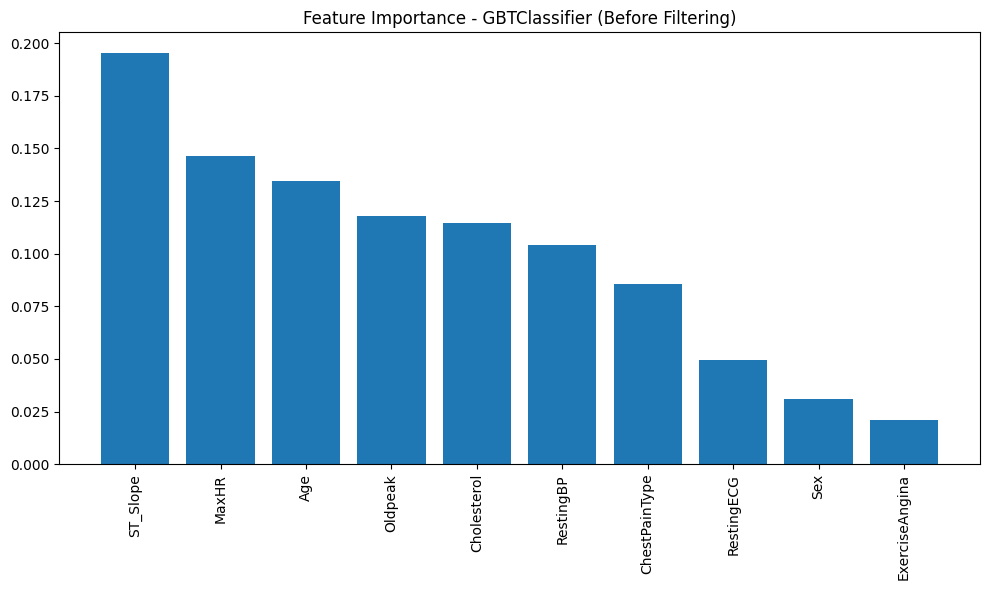

In [ ]:
importances = gbt_fitted_model.featureImportances.toArray()
importances = importances[:len(feature_names_for_importance)]

feature_importance_pairs = list(zip(feature_names_for_importance, importances))

sorted_pairs_desc = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)
features_sorted, importances_sorted = zip(*sorted_pairs_desc)

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - GBTClassifier (Before Filtering)")
plt.bar(range(len(importances_sorted)), importances_sorted, align="center")
plt.xticks(range(len(importances_sorted)), features_sorted, rotation=90)
plt.tight_layout()
plt.show()


**Loại bỏ đặc trưng ít quan trọng**

In [ ]:
# Sắp xếp tăng dần để loại đặc trưng ít nhất
sorted_pairs = sorted(feature_importance_pairs, key=lambda x: x[1])

# Lấy danh sách đặc trưng đã loại bỏ 2 cái ít nhất
important_features = [feature for feature, _ in sorted_pairs[2:]]

print("Các đặc trưng quan trọng (sau khi loại 2 đặc trưng ít nhất):", important_features)


Các đặc trưng quan trọng (sau khi loại 2 đặc trưng ít nhất): ['RestingECG', 'ChestPainType', 'RestingBP', 'Cholesterol', 'Oldpeak', 'Age', 'MaxHR', 'ST_Slope']


**Huấn luyện lại mô hình**

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Tạo assembler mới
filtered_assembler = VectorAssembler(inputCols=important_features, outputCol="filtered_features")
data_filtered = filtered_assembler.transform(df)

# Dữ liệu sau khi đã biến đổi
final_data = data_filtered.select("filtered_features", col("HeartDisease").alias("label"))


In [ ]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Tách tập train/test
train_data_filtered, test_data_filtered = final_data.randomSplit([0.8, 0.2], seed=42)

# Huấn luyện lại mô hình
gbt_new = GBTClassifier(labelCol="label", featuresCol="filtered_features", maxIter=50)
gbt_new_model = gbt_new.fit(train_data_filtered)

# Dự đoán
predictions_filtered = gbt_new_model.transform(test_data_filtered)

# Đánh giá
evaluator_filtered = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

evaluator_filtered.setMetricName("accuracy")
acc_filtered = evaluator_filtered.evaluate(predictions_filtered)

evaluator_filtered.setMetricName("weightedPrecision")
prec_filtered = evaluator_filtered.evaluate(predictions_filtered)

evaluator_filtered.setMetricName("weightedRecall")
rec_filtered = evaluator_filtered.evaluate(predictions_filtered)

evaluator_filtered.setMetricName("f1")
f1_filtered = evaluator_filtered.evaluate(predictions_filtered)

print(f"\n=== GBTClassifier with Filtered Features ===")
print(f"Accuracy: {acc_filtered:.4f}")
print(f"Precision: {prec_filtered:.4f}")
print(f"Recall: {rec_filtered:.4f}")
print(f"F1 Score: {f1_filtered:.4f}")



=== GBTClassifier with Filtered Features ===
Accuracy: 0.8322
Precision: 0.8330
Recall: 0.8322
F1 Score: 0.8317


**Nhận thấy rằng kết quả sau khi huấn luyện lại mô hình kém hơn so với ban đầu -> tối ưu hóa trên tập dữ liệu gốc.**

In [ ]:
def objective(trial):
    # Dùng GBTClassifier với các tham số được đề xuất từ Optuna
    gbt = GBTClassifier(
        maxDepth=trial.suggest_int("maxDepth", 2, 30, step=2),
        maxIter=trial.suggest_int("maxIter", 50, 200, step=25),
        stepSize=trial.suggest_float("stepSize", 0.01, 0.3, step=0.05),
        labelCol="label",
        featuresCol="features",
        seed=42
    )

    # Huấn luyện mô hình trên dữ liệu huấn luyện
    model = gbt.fit(train_data)

    # Dự đoán trên tập kiểm tra
    predictions = model.transform(test_data)

    # Đánh giá hiệu suất bằng F1-score
    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
    score = evaluator.evaluate(predictions)

    return score

# Tạo và tối ưu hóa Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

# In kết quả tốt nhất
print("Best Parameters:", study.best_params)
print("Best F1 Score:", study.best_value)

# Huấn luyện lại mô hình với tham số tối ưu
best_model_gbt = GBTClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=study.best_params["maxDepth"],
    maxIter=study.best_params["maxIter"],
    stepSize=study.best_params["stepSize"],
    seed=42
)

best_model_gbt_fitted = best_model_gbt.fit(train_data)

# Dự đoán trên tập kiểm tra
predictions_best_gbt = best_model_gbt_fitted.transform(test_data)

# Đánh giá mô hình tối ưu với các metric khác nhau
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

print("*" * 100)
acc_gbt = evaluator_acc.evaluate(predictions_best_gbt)
print(f"Accuracy on test set: {acc_gbt:.4f}")
recall_gbt = evaluator_rec.evaluate(predictions_best_gbt)
print(f"Recall on test set: {recall_gbt:.4f}")
pre_gbt = evaluator_prec.evaluate(predictions_best_gbt)
print(f"Precision on test set: {pre_gbt:.4f}")
f1_gbt = evaluator_f1.evaluate(predictions_best_gbt)
print(f"F1 Score on test set: {f1_gbt:.4f}")

# Lưu mô hình nếu cần thiết
# best_model_gbt_fitted.save("best_model_gbt") # Bỏ comment nếu muốn lưu


[I 2025-08-05 07:57:50,234] A new study created in memory with name: no-name-6c62d1e0-b2b0-418d-bc1c-634f0c864c02
[I 2025-08-05 08:06:46,284] Trial 0 finished with value: 0.7987849658612491 and parameters: {'maxDepth': 22, 'maxIter': 175, 'stepSize': 0.060000000000000005}. Best is trial 0 with value: 0.7987849658612491.
[I 2025-08-05 08:07:20,440] Trial 1 finished with value: 0.8649387054012267 and parameters: {'maxDepth': 2, 'maxIter': 200, 'stepSize': 0.16000000000000003}. Best is trial 1 with value: 0.8649387054012267.
[I 2025-08-05 08:12:52,294] Trial 2 finished with value: 0.8387656842719581 and parameters: {'maxDepth': 8, 'maxIter': 200, 'stepSize': 0.16000000000000003}. Best is trial 1 with value: 0.8649387054012267.
[I 2025-08-05 08:13:41,649] Trial 3 finished with value: 0.7987849658612491 and parameters: {'maxDepth': 22, 'maxIter': 50, 'stepSize': 0.21000000000000002}. Best is trial 1 with value: 0.8649387054012267.
[I 2025-08-05 08:17:11,135] Trial 4 finished with value: 0.7

Best Parameters: {'maxDepth': 2, 'maxIter': 200, 'stepSize': 0.16000000000000003}
Best F1 Score: 0.8649387054012267
****************************************************************************************************
Accuracy on test set: 0.8658
Recall on test set: 0.8658
Precision on test set: 0.8692
F1 Score on test set: 0.8649


# **=> Kết luận:** Thuật toán Random Forest là thuật toán tốt nhất, phù hợp nhất cho bài toán dự đoán nguy cơ mắc bệnh suy tim với giá trị Recall cao nhất